# KMeans 개선안 1: n_init 증가

KMeans는 초기 중심점 선택에 따라 결과가 달라질 수 있습니다. `n_init` 값을 늘려 여러 번 초기화한 뒤 가장 좋은 결과를 선택하도록 개선합니다.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

data_path = Path('fruits_300.npy')
if not data_path.exists():
    urlretrieve('https://bit.ly/fruits_300_data', data_path)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

fruits = np.load('fruits_300.npy')
fruits_2d = fruits.reshape(-1, 100 * 100)


In [3]:
def draw_fruits(arr, ratio=1):
    n = len(arr)
    rows = int(np.ceil(n / 10))
    cols = n if rows < 2 else 10
    fig, axs = plt.subplots(rows, cols, figsize=(cols * ratio, rows * ratio), squeeze=False)
    for i in range(rows):
        for j in range(cols):
            idx = i * 10 + j
            if idx < n:
                axs[i, j].imshow(arr[idx], cmap='gray_r')
            axs[i, j].axis('off')
    plt.show()


In [4]:
km = KMeans(n_clusters=3, n_init=20, random_state=42)
km.fit(fruits_2d)

print('labels:', np.unique(km.labels_, return_counts=True))
print('inertia:', km.inertia_)
print('n_iter:', km.n_iter_)


labels: (array([0, 1, 2], dtype=int32), array([ 91,  98, 111]))
inertia: 5074977316.088372
n_iter: 4


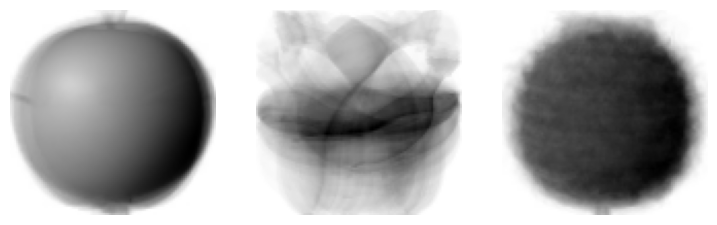

In [5]:
draw_fruits(km.cluster_centers_.reshape(-1, 100, 100), ratio=3)
